# Notebook 5 — Evaluation & Comparison

**Input:** All 4 `.pkl` model files + test arrays

**Output:** Per-model reports + final comparison table + charts

---

## Metrics used

| Metric | Why it matters for NIDS |
|---|---|
| **Accuracy** | Overall correct predictions — misleading on imbalanced data alone |
| **F1 (weighted)** | Balances precision and recall across all classes |
| **Recall (macro)** | How well we catch attacks — missing an attack (FN) is dangerous |
| **ROC-AUC** | Overall discriminating power — 1.0 = perfect |
| **Confusion Matrix** | Shows exactly which attack types get confused |
| **Train time** | Practical deployment consideration |

---

## Note on SVM
SVM is evaluated on **binary** labels (0=BENIGN, 1=ATTACK). All others on 7-class labels.

In [1]:
import numpy as np
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, recall_score, roc_auc_score
)

DATA_DIR = r'D:\Computer Engineering 2022\4-CE.Z Forth Year\second-semester-4.2\project\ML-NIDS-Android\03-dataset\02-processed'

X_test  = np.load(os.path.join(DATA_DIR, 'X_test_sc.npy'))
y_test  = np.load(os.path.join(DATA_DIR, 'y_test.npy'))
y_test_bin = (y_test > 0).astype(int)

LABEL_NAMES = ['BENIGN','DoS','DDoS','PortScan','BruteForce','WebAttack','Bot']

# Load models
rf   = joblib.load(os.path.join(DATA_DIR, 'model_rf.pkl'))
xgb  = joblib.load(os.path.join(DATA_DIR, 'model_xgb.pkl'))
lgbm = joblib.load(os.path.join(DATA_DIR, 'model_lgbm.pkl'))
svm  = joblib.load(os.path.join(DATA_DIR, 'model_svm.pkl'))

print('All models loaded.')

All models loaded.


In [2]:
# ── Evaluate each model ───────────────────────────────────────────────────────
def evaluate_multiclass(name, model, X, y, label_names):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)
    acc     = accuracy_score(y, y_pred)
    f1      = f1_score(y, y_pred, average='weighted')
    rec     = recall_score(y, y_pred, average='macro')
    try:
        auc = roc_auc_score(y, y_proba, multi_class='ovr', average='weighted')
    except:
        auc = float('nan')
    print(f'\n=== {name} ===')
    print(f'Accuracy      : {acc:.4f}')
    print(f'F1 (weighted) : {f1:.4f}')
    print(f'Recall (macro): {rec:.4f}')
    print(f'ROC-AUC       : {auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y, y_pred, target_names=label_names))
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'Recall': rec, 'ROC-AUC': auc, 'y_pred': y_pred}

def evaluate_binary(name, model, X, y):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    acc     = accuracy_score(y, y_pred)
    f1      = f1_score(y, y_pred, average='weighted')
    rec     = recall_score(y, y_pred, average='macro')
    auc     = roc_auc_score(y, y_proba)
    print(f'\n=== {name} (binary) ===')
    print(f'Accuracy      : {acc:.4f}')
    print(f'F1 (weighted) : {f1:.4f}')
    print(f'Recall (macro): {rec:.4f}')
    print(f'ROC-AUC       : {auc:.4f}')
    print('\nClassification Report:')
    print(classification_report(y, y_pred, target_names=['BENIGN', 'ATTACK']))
    return {'Model': name, 'Accuracy': acc, 'F1': f1, 'Recall': rec, 'ROC-AUC': auc, 'y_pred': y_pred}

results = []
results.append(evaluate_multiclass('Random Forest', rf,   X_test, y_test,     LABEL_NAMES))
results.append(evaluate_multiclass('XGBoost',       xgb,  X_test, y_test,     LABEL_NAMES))
results.append(evaluate_multiclass('LightGBM',      lgbm, X_test, y_test,     LABEL_NAMES))
results.append(evaluate_binary(    'SVM (binary)',  svm,  X_test, y_test_bin))


=== Random Forest ===
Accuracy      : 0.9996
F1 (weighted) : 0.9996
Recall (macro): 0.9884
ROC-AUC       : 1.0000

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    454264
         DoS       1.00      1.00      1.00     50343
        DDoS       1.00      1.00      1.00     25605
    PortScan       1.00      1.00      1.00     31761
  BruteForce       1.00      1.00      1.00      2766
   WebAttack       0.99      0.99      0.99       436
         Bot       0.97      0.93      0.95       391

    accuracy                           1.00    565566
   macro avg       0.99      0.99      0.99    565566
weighted avg       1.00      1.00      1.00    565566


=== XGBoost ===
Accuracy      : 0.9993
F1 (weighted) : 0.9993
Recall (macro): 0.9998
ROC-AUC       : 1.0000

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    454264
         DoS       0.9

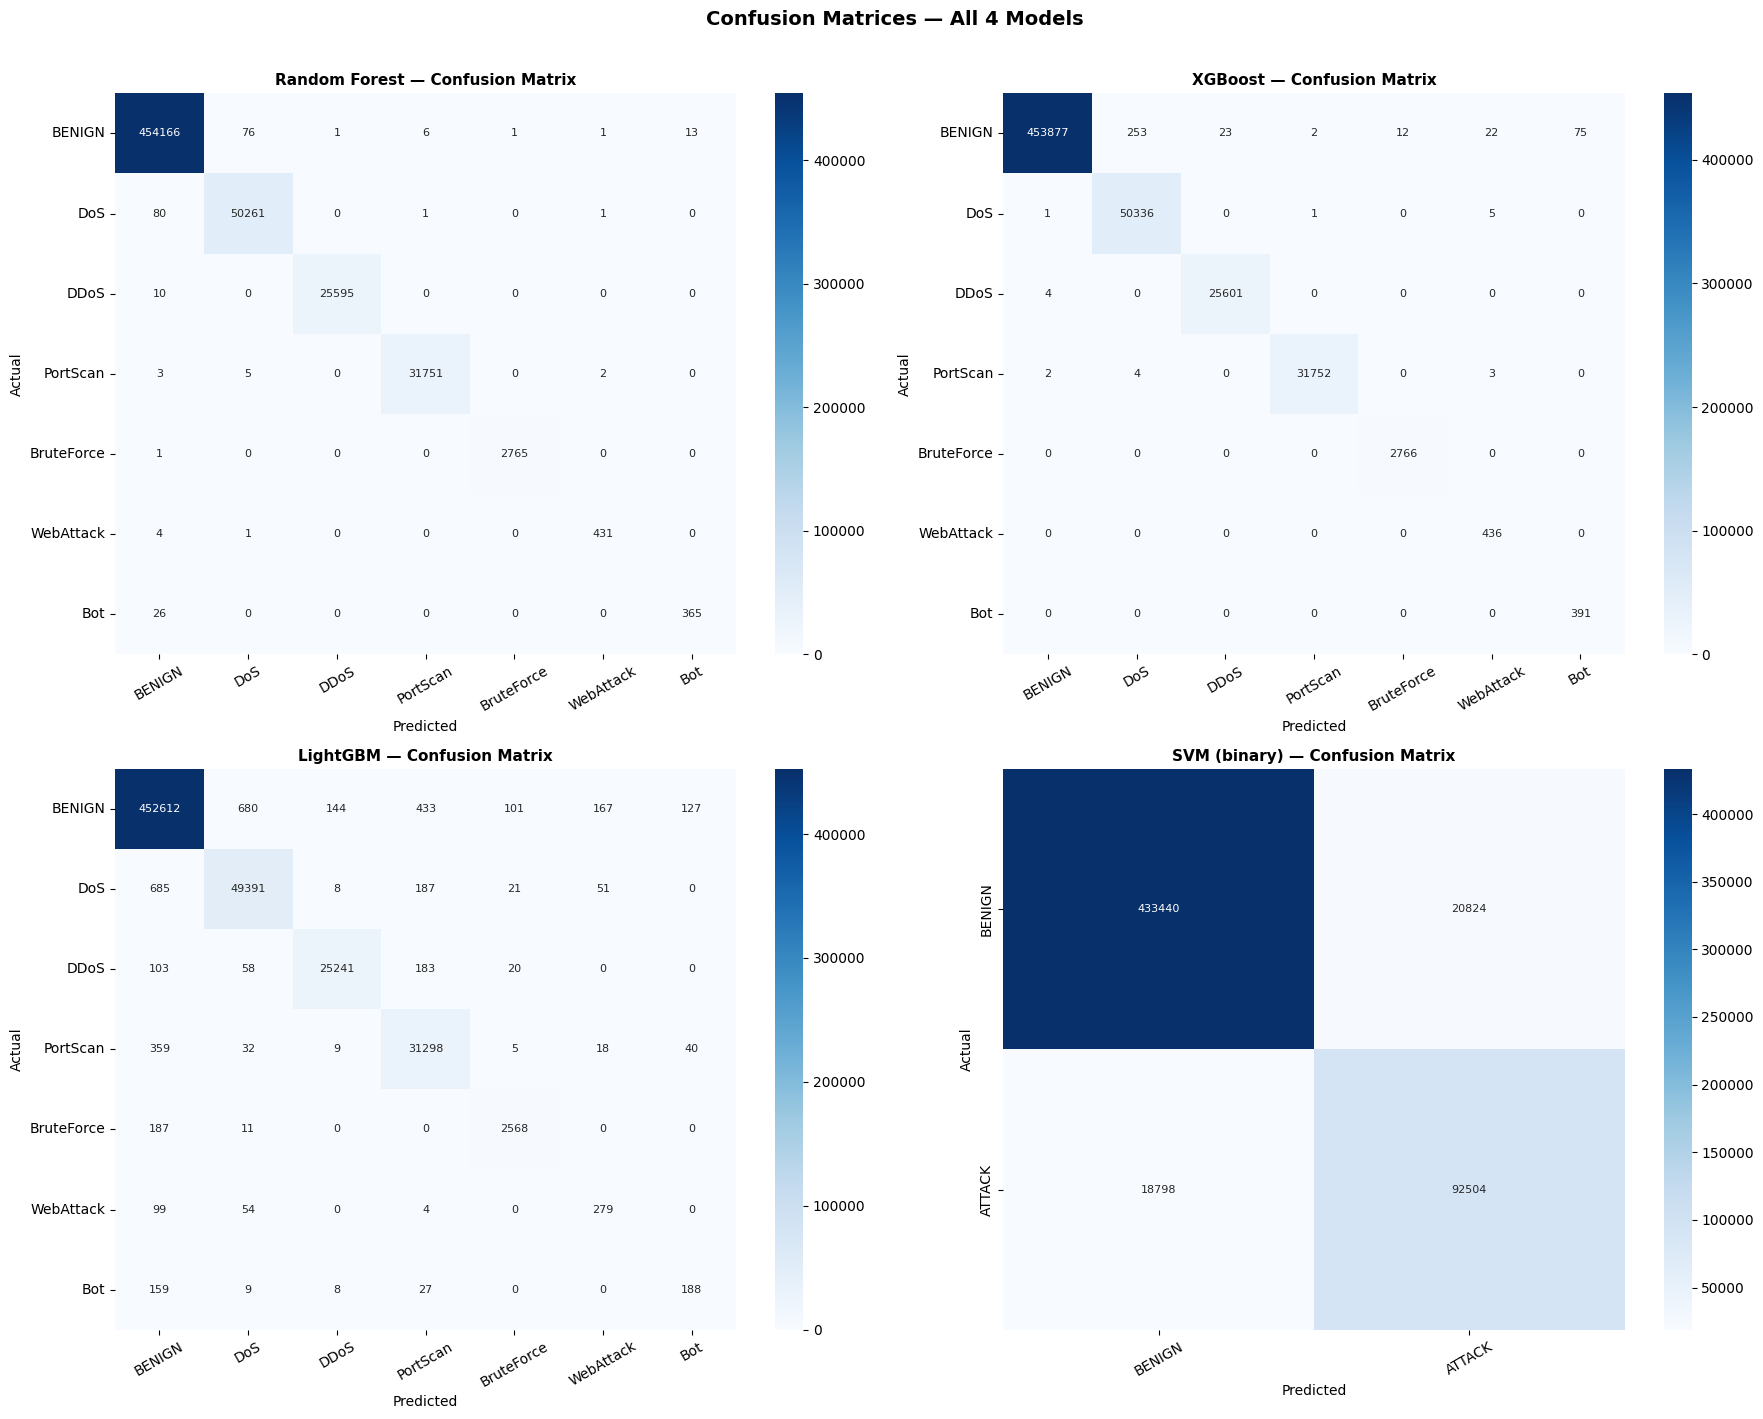

Saved 05_confusion_matrices.png


In [3]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

model_list  = [rf, xgb, lgbm, svm]
model_names = ['Random Forest', 'XGBoost', 'LightGBM', 'SVM (binary)']
y_tests     = [y_test, y_test, y_test, y_test_bin]
label_lists = [LABEL_NAMES, LABEL_NAMES, LABEL_NAMES, ['BENIGN','ATTACK']]

for i, (model, name, yt, lnames) in enumerate(zip(model_list, model_names, y_tests, label_lists)):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(yt, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=lnames, yticklabels=lnames,
                annot_kws={'size': 8})
    axes[i].set_title(f'{name} — Confusion Matrix', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved 05_confusion_matrices.png')

In [4]:
# ── Final comparison table ────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'Model'     : r['Model'],
    'Accuracy'  : f"{r['Accuracy']*100:.2f}%",
    'F1'        : f"{r['F1']*100:.2f}%",
    'Recall'    : f"{r['Recall']*100:.2f}%",
    'ROC-AUC'   : f"{r['ROC-AUC']:.4f}",
} for r in results])

print('\n=== FINAL COMPARISON TABLE ===')
print(summary.to_string(index=False))


=== FINAL COMPARISON TABLE ===
        Model Accuracy     F1 Recall ROC-AUC
Random Forest   99.96% 99.96% 98.84%  1.0000
      XGBoost   99.93% 99.93% 99.98%  1.0000
     LightGBM   99.29% 99.30% 85.68%  0.9915
 SVM (binary)   92.99% 93.02% 89.26%  0.9754


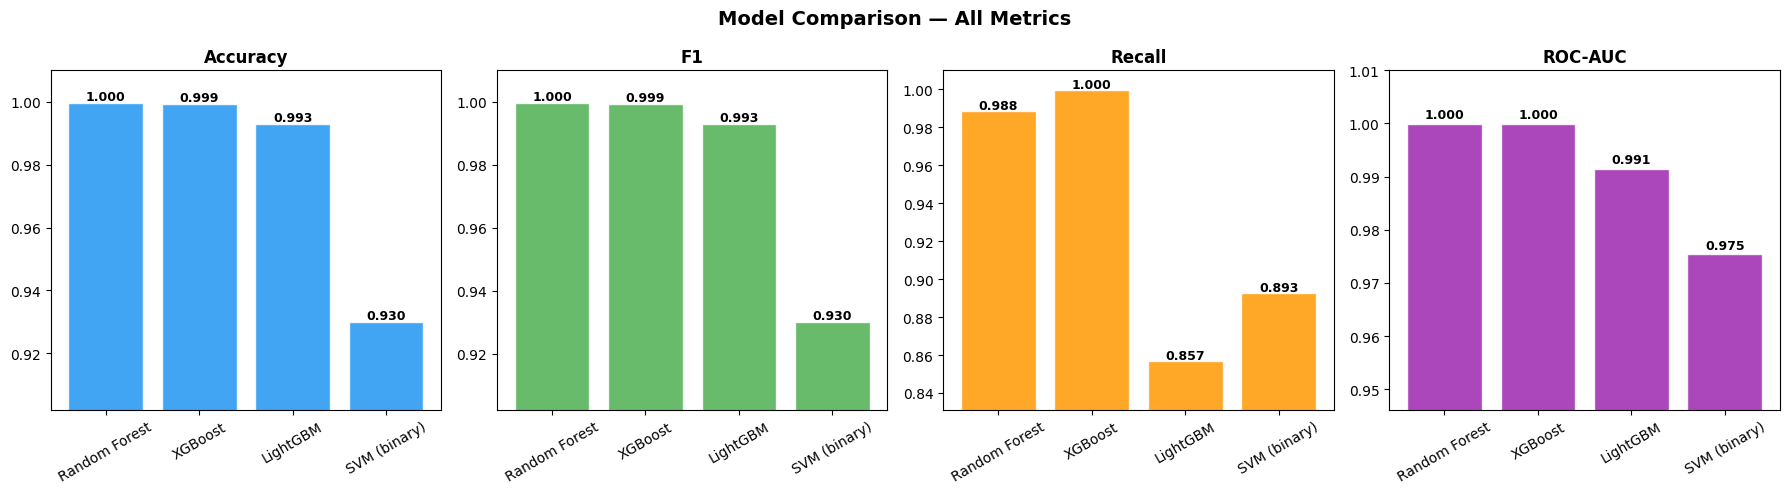

Saved 05_model_comparison.png


In [5]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
metric_data = pd.DataFrame([{
    'Model'   : r['Model'],
    'Accuracy': r['Accuracy'],
    'F1'      : r['F1'],
    'Recall'  : r['Recall'],
    'ROC-AUC' : r['ROC-AUC'],
} for r in results])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Accuracy', 'F1', 'Recall', 'ROC-AUC']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = metric_data[metric].values
    bars = axes[i].bar(metric_data['Model'], vals, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(metric, fontweight='bold', fontsize=12)
    axes[i].set_ylim(min(vals) * 0.97, 1.01)
    axes[i].tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_model_comparison.png', dpi=150)
plt.show()
print('Saved 05_model_comparison.png')

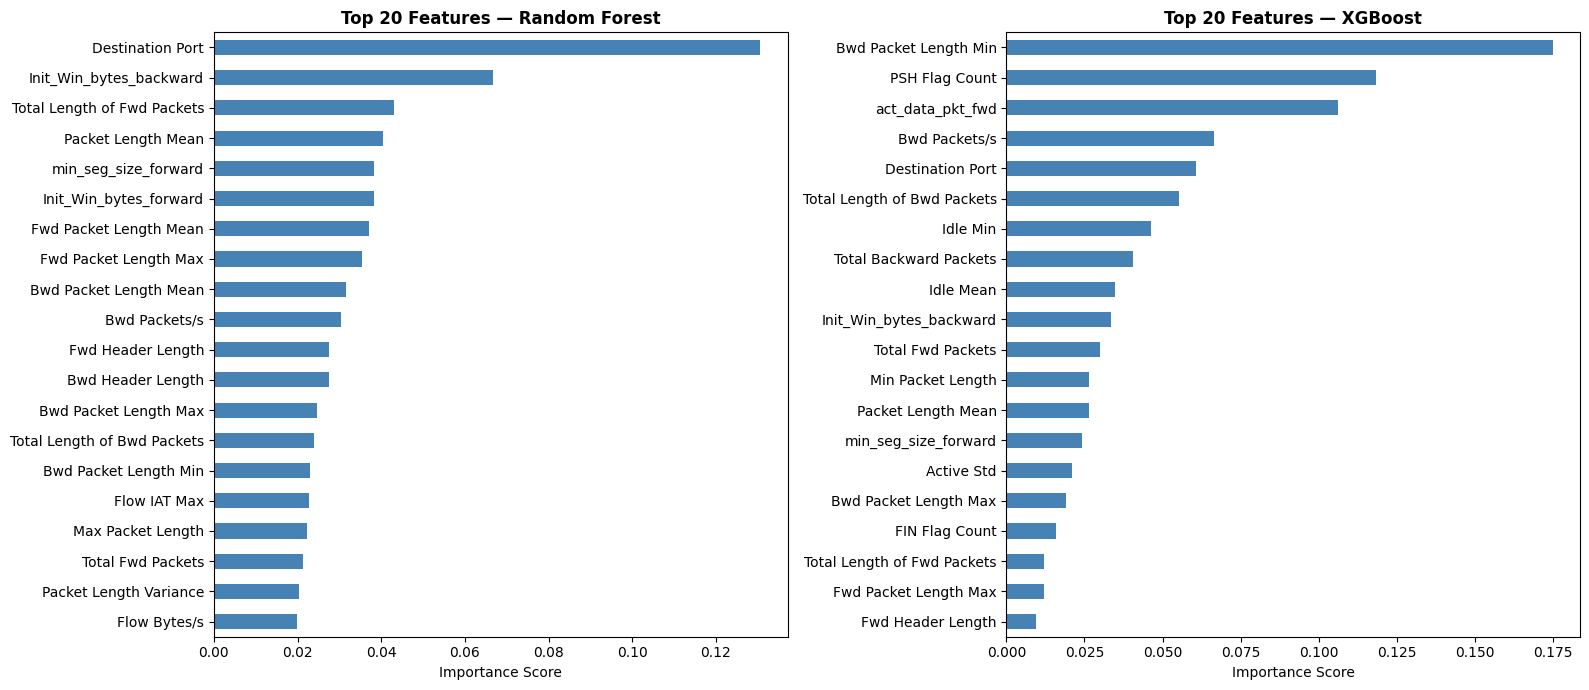

Saved 05_feature_importance.png

Evaluation complete.


In [6]:
# ── Feature importance (RF and XGBoost) ──────────────────────────────────────
feature_cols = joblib.load(os.path.join(DATA_DIR, 'feature_cols.pkl'))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name in zip(axes, [rf, xgb], ['Random Forest', 'XGBoost']):
    fi = pd.Series(model.feature_importances_, index=feature_cols)
    fi = fi.sort_values(ascending=True).tail(20)
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 Features — {name}', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150)
plt.show()
print('Saved 05_feature_importance.png')
print('\nEvaluation complete.')